In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from decision_tree_regressor import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
df= pd.read_csv('../../datasets/cardekho_data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [4]:
#renaming columns
df.columns= df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['car_name', 'year', 'selling_price', 'present_price', 'kms_driven',
       'fuel_type', 'seller_type', 'transmission', 'owner'],
      dtype='object')

In [5]:
#checking for null values
df.isna().sum()

car_name         0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
seller_type      0
transmission     0
owner            0
dtype: int64

In [6]:
#dropping duplicates
df= df.drop_duplicates()

array([[<Axes: title={'center': 'selling_price'}>,
        <Axes: title={'center': 'present_price'}>],
       [<Axes: title={'center': 'kms_driven'}>, <Axes: >]], dtype=object)

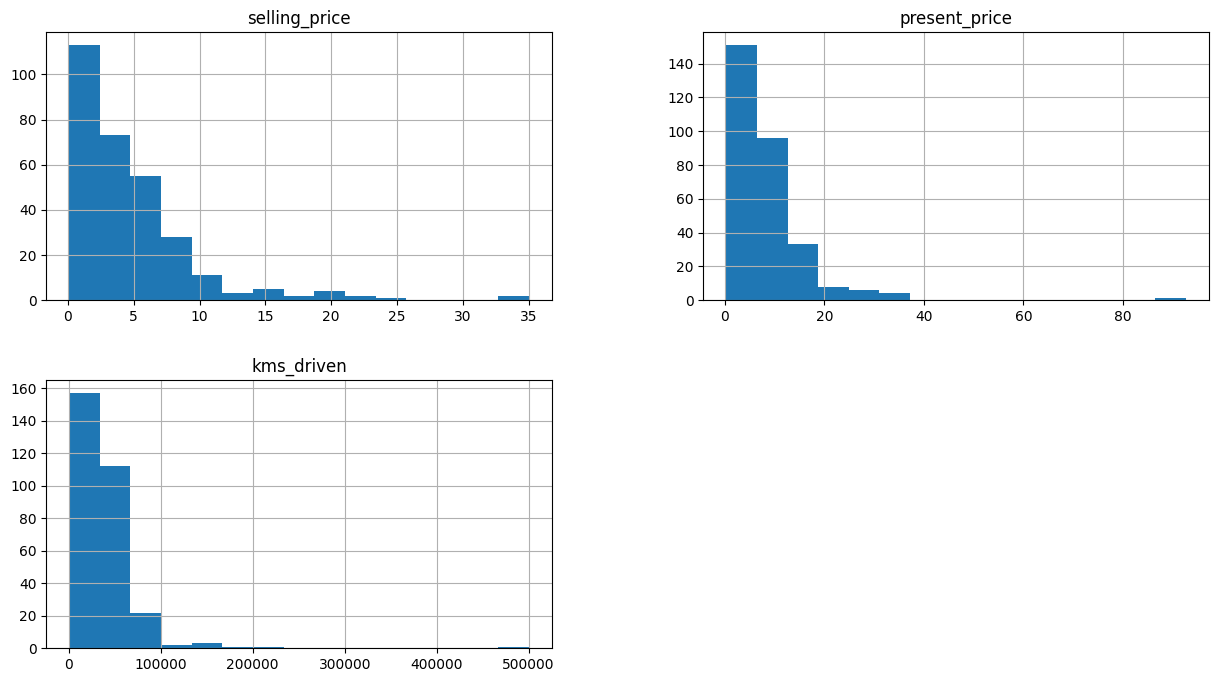

In [7]:
#checking distributions
num_cols= ['selling_price', 'present_price', 'kms_driven',]
cat_cols= ['fuel_type', 'seller_type', 'transmission', 'owner']

df[num_cols].hist(bins= 15, figsize= (15, 8))

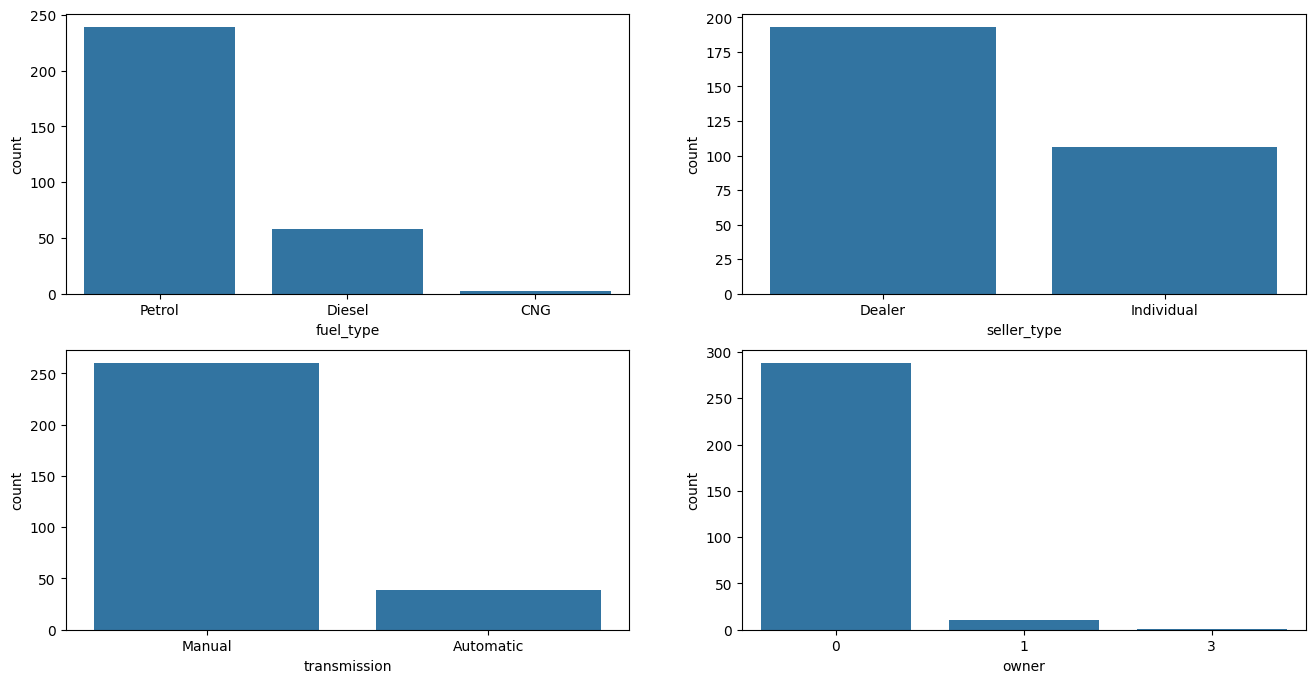

In [8]:
fig, ax= plt.subplots(2, 2, figsize= (16, 8))
for index, col in enumerate(cat_cols):
    sns.countplot(x= df[col], ax= ax.flatten()[index])

In [9]:
#lookign at the outliers in input (not necessary for dtr)
print(df['present_price'].quantile([0.1, 0.25, 0.5, 0.75, 0.90, 0.99, 1.0]))
df[df['present_price'] >= df['present_price'].quantile(0.99)]

0.10     0.706
0.25     1.200
0.50     6.100
0.75     9.840
0.90    14.790
0.99    35.960
1.00    92.600
Name: present_price, dtype: float64


,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
59,fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0
62,fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0
63,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0
64,fortuner,2017,33.00,36.23,6000,Diesel,Dealer,Automatic,0
86,land cruiser,2010,35.00,92.60,78000,Diesel,Dealer,Manual,0


In [10]:
# splitting train test data
X= df.drop(['car_name', 'selling_price'], axis= 1)
y= df[['selling_price']]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 19, test_size= 0.2)

In [11]:
# encoding  
num_cols= ['year', 'present_price', 'kms_driven']

transformer= ColumnTransformer(
    [('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), cat_cols)
    ]
)

X_train= transformer.fit_transform(X_train)
y_train= y_train.values

In [12]:
#fitting model
model= DecisionTreeRegressor(min_samples_split= 5, max_depth= 4)
model.fit(X_train, y_train) 

In [13]:
#prediction
X_test= transformer.transform(X_test)
y_test= y_test.values

y_pred= model.predict(X_test)

In [14]:
r2 = r2_score(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
mae= mean_absolute_error(y_test, y_pred)

print(f'r2 score= {r2}')
print(f'mean squared error= {mse}')
print(f'mean squared error= {mae}')

r2 score= 0.8891485218626853
mean squared error= 2.910244811535066
mean squared error= 0.9914654164792797


## Comparing with baseline sklearn Decision Tree Regressor

In [15]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
dtr= DecisionTreeRegressor(min_samples_split= 5, max_depth= 4)
dtr.fit(X_train, y_train)
y_pred_expected= dtr.predict(X_test) 

In [16]:
expected_r2 = r2_score(y_test, y_pred_expected)
expected_mse= mean_squared_error(y_test, y_pred_expected)
expected_mae= mean_absolute_error(y_test, y_pred_expected)

print(f'r2 score= {expected_r2}')
print(f'mean squared error= {expected_mse}')
print(f'mean squared error= {expected_mae}')

r2 score= 0.8293467995567635
mean squared error= 4.480252311535065
mean squared error= 1.1809654164792796


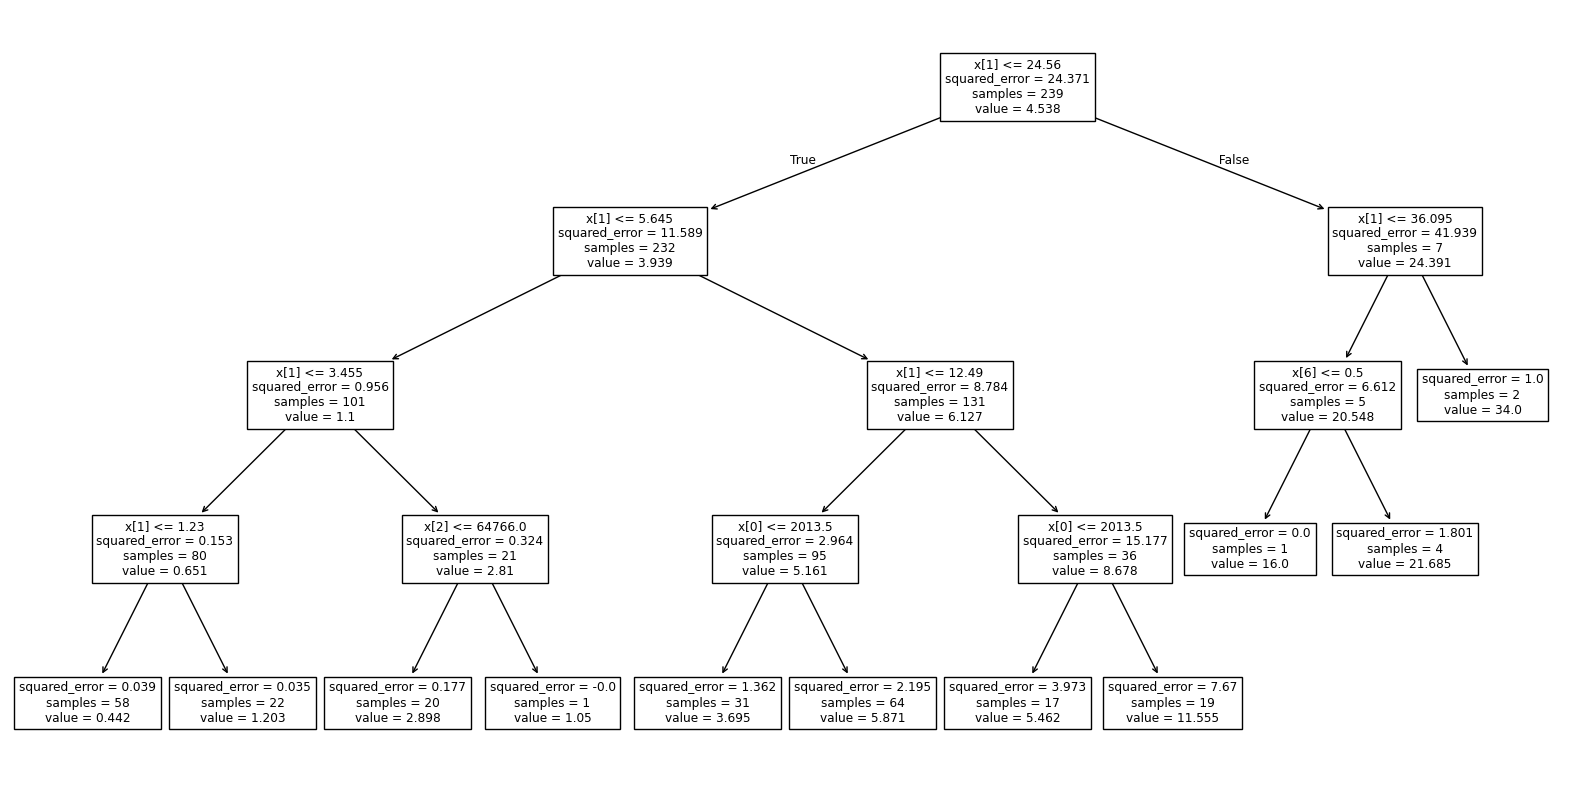

In [17]:
fig, ax= plt.subplots(1, 1, figsize= (20, 10) )
plot_tree(dtr, ax= ax)
plt.show()